## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [ ]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

In [ ]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## Inserting a Target Column "class"

In [ ]:
df_fake["class"] = 0
df_true["class"] = 1

In [ ]:
df_fake.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
df_true.head()

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [ ]:
df_fake.shape, df_true.shape

((23481, 5), (21417, 5))

## Removing last 10 rows for manual testing

In [ ]:
df_fake_manual_testing = df_fake.tail(10)
for i in range(23480,23470,-1):
    df_fake.drop([i], axis = 0, inplace = True)


df_true_manual_testing = df_true.tail(10)
for i in range(21416,21406,-1):
    df_true.drop([i], axis = 0, inplace = True)

In [ ]:
df_fake.shape, df_true.shape

((23471, 5), (21407, 5))

In [ ]:
df_fake_manual_testing["class"] = 0
df_true_manual_testing["class"] = 1

/tmp/ipykernel_3411/860779283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fake_manual_testing["class"] = 0
/tmp/ipykernel_3411/860779283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_true_manual_testing["class"] = 1


In [ ]:
df_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [ ]:
df_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


## Combining and Saving Manual Testing Dataset

In [ ]:
df_manual_testing = pd.concat([df_fake_manual_testing,df_true_manual_testing], axis = 0)
df_manual_testing.to_csv("manual_testing.csv")

## Merging True and Fake DataFrames

In [ ]:
df_merge = pd.concat([df_fake, df_true], axis =0 )
df_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [ ]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [ ]:
df = df_merge.drop(["title", "subject","date"], axis = 1)

In [ ]:
df.isnull().sum()

,0
text,0
class,0


In [ ]:
df = df.sample(frac = 1)

In [ ]:
df.head()

,text,class
13115,SYDNEY (Reuters) - Several lawmakers filed fam...,1
22328,"This week, the momentum in Syria shifted dram...",0
10963,WASHINGTON (Reuters) - Former U.S. Secretary o...,1
17515,VIENNA (Reuters) - The chief of the U.N. atomi...,1
11741,MOSCOW (Reuters) - Russia may decide to design...,1


In [ ]:
df.reset_index(inplace = True)
df.drop(["index"], axis = 1, inplace = True)

In [ ]:
df.columns

Index(['text', 'class'], dtype='object')

In [ ]:
df.head()

,text,class
0,SYDNEY (Reuters) - Several lawmakers filed fam...,1
1,"This week, the momentum in Syria shifted dram...",0
2,WASHINGTON (Reuters) - Former U.S. Secretary o...,1
3,VIENNA (Reuters) - The chief of the U.N. atomi...,1
4,MOSCOW (Reuters) - Russia may decide to design...,1


## Creating a Text Preprocessing Function

In [ ]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_3411/2411212894.py:3: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipykernel_3411/2411212894.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipykernel_3411/2411212894.py:9: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [ ]:
df["text"] = df["text"].apply(wordopt)

## Defining Dependent and Independent Variables

In [ ]:
x = df["text"]
y = df["class"]

## Splitting Training and Testing Sets

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

## Converting Text to Vectors

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer(stop_words='english', max_features=10000)

xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

## Training a Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [ ]:
pred_lr=LR.predict(xv_test)

In [ ]:
LR.score(xv_test, y_test)

0.9873440285204991

In [ ]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5996
           1       0.98      0.99      0.99      5224

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



## Model Testing

In [ ]:
def output_lable(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    return print("\n\nLR Prediction: {}".format(output_lable(pred_LR[0])))

In [ ]:
news = str(input())
manual_testing(news)

WASHINGTON (AP) — President Donald Trump returned from the spectacle of a Chinese state visit to a less than welcoming U.S. economy — with the military band and garden tour in Beijing giving way to pressure over how to fix America’s escalating inflation rate.


LR Prediction: Fake News


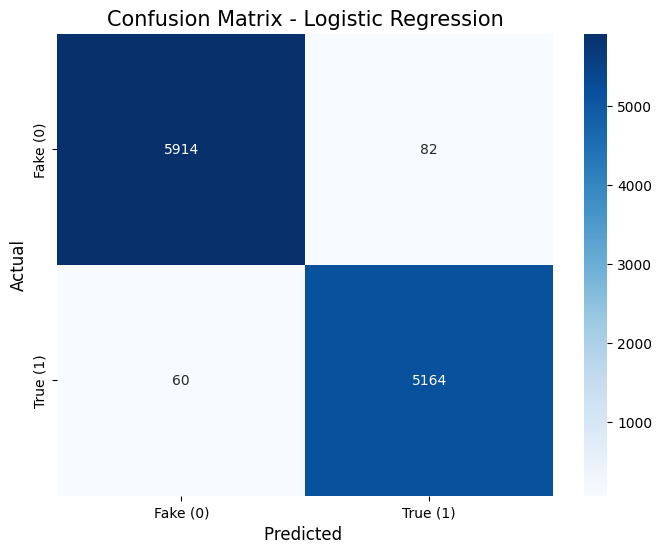

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'True (1)'],
            yticklabels=['Fake (0)', 'True (1)'])

plt.title('Confusion Matrix - Logistic Regression', fontsize=15)
plt.xlabel('Predicted ', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


# Deep Learning (NN)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_nn = Sequential()

model_nn.add(Dense(128, activation='relu', input_shape=(xv_train.shape[1],)))
model_nn.add(Dropout(0.5))

model_nn.add(Dense(64, activation='relu'))
model_nn.add(Dropout(0.5))


model_nn.add(Dense(1, activation='sigmoid'))

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_nn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

# Training & Validation

In [ ]:
xv_train.sort_indices()
xv_test.sort_indices()

print("Training Neural Network...")

history = model_nn.fit(
    xv_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Training Neural Network...
Epoch 1/5
421/421 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9561 - loss: 0.1471 - val_accuracy: 0.9868 - val_loss: 0.0408
Epoch 2/5
421/421 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9952 - loss: 0.0185 - val_accuracy: 0.9889 - val_loss: 0.0365
Epoch 3/5
421/421 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9986 - loss: 0.0063 - val_accuracy: 0.9886 - val_loss: 0.0396
Epoch 4/5
421/421 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.9883 - val_loss: 0.0454
Epoch 5/5
421/421 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9895 - val_loss: 0.0502


# Model Evaluation

In [ ]:
loss, accuracy = model_nn.evaluate(xv_test, y_test)
print(f"\nNeural Network Accuracy: {accuracy * 100:.2f}%\n")

pred_nn_prob = model_nn.predict(xv_test)

pred_nn = (pred_nn_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report
print("Deep Learning Classification Report:")
print(classification_report(y_test, pred_nn, target_names=['Fake (0)', 'True (1)']))


351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9883 - loss: 0.0532

Neural Network Accuracy: 98.83%

351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Deep Learning Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      5996
    True (1)       0.99      0.99      0.99      5224

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



#  LLM (Hugging Face)

In [ ]:
from transformers import pipeline

print("Loading LLM Model...")
llm_classifier = pipeline("text-classification")

fake_sample = df_fake['text'].iloc[0][:500]
true_sample = df_true['text'].iloc[0][:500]

print("\n==================================")
print("--- Fake News Sample Prediction ---")
print("Prediction:", llm_classifier(fake_sample))

print("\n==================================")
print("--- True News Sample Prediction ---")
print("Prediction:", llm_classifier(true_sample))
print("==================================")



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading LLM Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


--- Fake News Sample Prediction ---
Prediction: [{'label': 'NEGATIVE', 'score': 0.9938173890113831}]

--- True News Sample Prediction ---
Prediction: [{'label': 'POSITIVE', 'score': 0.7216039896011353}]


In [ ]:
from transformers import pipeline

print("Loading Fake News LLM Model...")
fake_news_classifier = pipeline("text-classification", model="mrm8488/bert-tiny-finetuned-fake-news-detection")

print("\n==================================")
print("--- Fake News Sample Prediction ---")
print("Prediction:", fake_news_classifier(fake_sample))

print("\n==================================")
print("--- True News Sample Prediction ---")
print("Prediction:", fake_news_classifier(true_sample))
print("==================================")


Loading Fake News LLM Model...


config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mrm8488/bert-tiny-finetuned-fake-news-detection
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


--- Fake News Sample Prediction ---
Prediction: [{'label': 'LABEL_1', 'score': 0.999289870262146}]

--- True News Sample Prediction ---
Prediction: [{'label': 'LABEL_0', 'score': 0.9993137121200562}]


# Deployment

In [ ]:
import gradio as gr
import numpy as np

def ai_committee_prediction(news_text):
    try:
        cleaned_text = wordopt(news_text)
        vectorized_text = vectorization.transform([cleaned_text])
    except Exception as e:
        return f"Error Setup: {str(e)}", "Error", "Error", "Error"

    votes_for_true = 0

    try:
        lr_pred = LR.predict(vectorized_text)[0]
        if lr_pred == 1:
            votes_for_true += 1
            lr_result = "✅ True News"
        else:
            lr_result = "🚨 Fake News"
    except Exception as e:
        lr_result = f"Error: {str(e)}"

    try:
        nn_prob = model_nn.predict(vectorized_text.toarray())[0][0]
        if nn_prob >= 0.5:
            votes_for_true += 1
            nn_result = f"✅ True News (Confidence: {nn_prob*100:.1f}%)"
        else:
            nn_result = f"🚨 Fake News (Confidence: {(1-nn_prob)*100:.1f}%)"
    except Exception as e:
        nn_result = f"Error: {str(e)}"

    try:
        if 'fake_news_classifier' in globals():
            hf_model = fake_news_classifier
        elif 'llm_classifier' in globals():
            hf_model = llm_classifier
        else:
            raise ValueError("Please run Phase 4 first!")

        hf_output = hf_model(news_text[:500])[0]
        hf_label = hf_output['label']
        hf_score = hf_output['score']

        if hf_label == 'LABEL_0' or hf_label == 'POSITIVE':
            votes_for_true += 1
            hf_result = f"✅ True News (Confidence: {hf_score*100:.1f}%)"
        else:
            hf_result = f"🚨 Fake News (Confidence: {hf_score*100:.1f}%)"
    except Exception as e:
        hf_result = f"Error: {str(e)}"

    if votes_for_true >= 2:
        final_verdict = f"✅ TRUE NEWS (Majority Vote: {votes_for_true} out of 3 models)"
    else:
        fake_votes = 3 - votes_for_true
        final_verdict = f"🚨 FAKE NEWS (Majority Vote: {fake_votes} out of 3 models)"

    return lr_result, nn_result, hf_result, final_verdict

app = gr.Interface(
    fn=ai_committee_prediction,
    inputs=gr.Textbox(lines=6, placeholder="Paste the news article here to be judged by the AI Committee..."),
    outputs=[
        gr.Text(label="🤖 Machine Learning (Logistic Regression)"),
        gr.Text(label="🧠 Deep Learning (Neural Network)"),
        gr.Text(label="🌐 Global LLM (Hugging Face)"),
        gr.Text(label="⚖️ Final Verdict (Majority Vote)")
    ],
    title="🏛️ The Supreme AI Committee for Fake News",
    description="Why trust one AI when you can ask three? This dashboard sends your news to Machine Learning, Deep Learning, and a Global LLM simultaneously, and makes the final decision by democratic majority vote!"
)

app.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://11f6452ea88755f08d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
